# Full Forecasting Pipeline

**Docker image**: `ml4t`

The last four notebooks each built one piece. This one runs them as a sequence: a panel of
research agents, an aggregate over them, a debate between two sides of the aggregate, and a
supervisor that reads the panel, searches where the agents disagreed, and decides whether to
override. That is the **AIA Forecaster** architecture, and the point of assembling it is not
that four stages beat one; it is that a forecast produced this way can be taken apart when it
is wrong.

Both questions the pipeline runs on were unresolved when the capture was taken. It produces
probabilities and cannot be scored, and neither can any claim that a later stage improved on
an earlier one. Scoring against known outcomes is
[`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb).

**Learning Objectives**:
- Build a supervisor that finds where a panel disagreed, searches on those points, and
  returns its own probability
- Gate that supervisor's influence on the confidence it states, so it can adjust the ensemble
  without silently replacing it
- Compose four stages into one class whose settings are all declared in one place
- Read a stage-by-stage probability path and see which stage moved the answer
- Record a run in a form a scoring pipeline could later consume

**Book Reference**: Chapter 24, Sections 24.7 (Multi-agent forecasting systems) and 24.9
(Preparing for production)

**Prerequisites**: [`04_research_agent`](04_research_agent.ipynb),
[`05_aggregation_math`](05_aggregation_math.ipynb),
[`06_multi_agent_research`](06_multi_agent_research.ipynb),
[`07_adversarial_debate`](07_adversarial_debate.ipynb).

In [1]:
"""Full Forecasting Pipeline: agent-debate-supervisor end-to-end."""

import json
import textwrap
import time
from datetime import date, datetime

import matplotlib.pyplot as plt
import polars as pl
from agent_fixtures import get_chapter_clear_question, get_chapter_contested_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    show_agents,
    show_debate_transcript,
    show_supervisor,
    trace_llm,
)
from agent_pipeline import neyman_extremize
from agent_providers import ChatMessage, TokenUsage, create_llm_client
from agent_research import ResearchAgent, format_agent_summary, parse_json
from agent_schemas import (
    AgentForecastArtifact,
    ForecastQuestion,
    ForecastResult,
    SearchResult,
    SupervisorArtifact,
)
from agent_specialists import DebateAgent
from agent_tools import (
    SearchClient,
    ToolExecutor,
    create_search_client,
)
from IPython.display import Markdown, display

from utils.style import COLORS, add_message_title, show_with_alt

## Settings

`RUN_LIVE` left at `False` replays the two pinned captures, one per question, and makes no
API calls.

`N_AGENTS`, `MAX_STEPS` and `MAX_SEARCH_RESULTS` configure the research phase exactly as in
[`06_multi_agent_research`](06_multi_agent_research.ipynb). `DEBATE_ROUNDS` caps the
argument, and `NEYMAN_CORRELATION` is the pairwise correlation assumed when the panel is
aggregated.

Three weights decide how much each later stage can move the answer, and they are the numbers
to argue with. `DEBATE_WEIGHT` is the debate midpoint's share of the post-debate probability.
`SUPERVISOR_MEDIUM_WEIGHT` is the supervisor's share when it states medium confidence; at
high confidence it replaces the value outright and at low confidence it is ignored.

The three `CONFIDENCE_WHEN_*` values are what the pipeline reports as its own confidence in
each of those three cases. They are an ordering, not an estimate: a forecast the supervisor
overrode is marked as having had more reconciliation than one where it was ignored, and
nothing here measures whether either is more likely to be right.

In [2]:
RUN_LIVE = False
PINNED_TRACES = [
    "08_forecasting_pipeline_20260609T141954Z_ef5bca7b95bd.json",  # recession (clear)
    "08_forecasting_pipeline_20260609T142158Z_24e083e7fe54.json",  # rate hike (contested)
]
LLM_PROVIDER = ""
N_AGENTS = 3
DEBATE_ROUNDS = 3
MAX_STEPS = 5
MAX_SEARCH_RESULTS = 5
NEYMAN_CORRELATION = 0.3
DEBATE_WEIGHT = 0.3
SUPERVISOR_MEDIUM_WEIGHT = 0.4
CONFIDENCE_WHEN_OVERRIDDEN = 0.8
CONFIDENCE_WHEN_BLENDED = 0.6
CONFIDENCE_WHEN_IGNORED = 0.5

## Supervisor Prompts

The supervisor operates in two phases:
1. **Identify disagreements** among agents and propose clarifying searches
2. **Finalize** with updated probability, incorporating new evidence

These prompts are shown inline from the AIA Forecaster's production templates.

In [3]:
SUPERVISOR_DISAGREEMENTS_PROMPT = """\
You are the SUPERVISOR agent.

You receive M agent forecasts and rationales for the same question.
Your job is NOT to average them directly.

Step 1: Identify key disagreements, ambiguities, missing base rates, or claims that should be fact-checked.
Step 2: Propose up to {max_queries} clarifying search queries that would resolve these disagreements.

Output JSON only with:
{{"disagreements": ["..."], "queries": ["..."]}}

AGENT INPUTS:
{agent_summaries}"""

The finalize prompt receives the original question, agent panel, and bounded
follow-up evidence. It requests a probability, confidence label, and rationale.

In [4]:
SUPERVISOR_FINALIZE_PROMPT = """\
You are the SUPERVISOR agent.

Given:
1) The original question
2) The set of agent forecasts and rationales
3) Additional evidence from your follow-up searches

You must output:
1) Updated forecast p_yes in [0,1]
2) Confidence in whether your update direction is correct: "high" | "medium" | "low"
3) A short rationale

Output JSON only:
{{"p_yes": 0.0, "confidence": "high", "rationale": "..."}}

QUESTION:
{question}

AGENT INPUTS:
{agent_summaries}

SUPERVISOR SEARCH EVIDENCE:
{supervisor_evidence}"""

## Supervisor phase helpers

The supervisor's three phases (identify, search, finalize) factor
naturally into free functions. The class then becomes a thin shell that
owns the LLM + search clients and threads them through the helpers.

In [5]:
def _supervisor_identify_disagreements(
    llm,
    agent_summaries: str,
    max_queries: int,
) -> tuple[list[str], list[str], TokenUsage]:
    """Phase 1: LLM call asking for disagreements and clarifying queries."""
    prompt = SUPERVISOR_DISAGREEMENTS_PROMPT.format(
        max_queries=max_queries, agent_summaries=agent_summaries
    )
    raw, tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=prompt)], json_mode=True
    )
    parsed = parse_json(raw)
    disagreements = [str(x) for x in parsed.get("disagreements", [])][:20]
    queries = [str(x) for x in parsed.get("queries", [])][:max_queries]
    return disagreements, queries, tokens

The search phase executes only the supervisor's bounded query list and
applies the question's point-in-time cutoff to every request.

In [6]:
def _supervisor_run_searches(
    search,
    queries: list[str],
    max_search_results: int,
    cutoff_date: date | None,
) -> dict[str, list[SearchResult]]:
    """Phase 2: execute the clarifying-search queries via ToolExecutor."""
    if search is None:
        return {}
    executor = ToolExecutor(search=search)
    return {
        q: executor.execute_search(q, max_results=max_search_results, cutoff_date=cutoff_date)
        for q in queries
    }

Search results become a compact evidence block for the final model call.
Dates and source URLs remain visible for audit.

In [7]:
def _format_supervisor_evidence(sr: dict[str, list[SearchResult]]) -> str:
    """Render the search-result dict into the supervisor-finalize prompt's evidence block."""
    lines: list[str] = []
    for q, results in sr.items():
        lines.append(f"QUERY: {q}")
        for i, r in enumerate(results, start=1):
            lines.append(f"{i}. {r.title}")
            if r.url:
                lines.append(f"   URL: {r.url}")
            if r.snippet:
                lines.append(f"   {r.snippet}")
            if r.published:
                lines.append(f"   Published: {r.published}")
        lines.append("")
    return "\n".join(lines) if lines else "No additional search evidence."

The final phase parses and clamps the supervisor probability. Invalid
confidence labels fall back to `medium` instead of triggering an override.

In [8]:
def _supervisor_finalize(
    llm,
    question: str,
    agent_summaries: str,
    search_results: dict[str, list[SearchResult]],
) -> tuple[float | None, str | None, str | None, TokenUsage]:
    """Phase 3: LLM call asking for final p_yes / confidence / rationale."""
    evidence_text = _format_supervisor_evidence(search_results)
    prompt = SUPERVISOR_FINALIZE_PROMPT.format(
        question=question,
        agent_summaries=agent_summaries,
        supervisor_evidence=evidence_text,
    )
    raw, tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=prompt)], json_mode=True
    )
    parsed = parse_json(raw)
    p_yes_raw = parsed.get("p_yes")
    confidence = parsed.get("confidence")
    rationale = parsed.get("rationale")

    if confidence is not None:
        conf_str = str(confidence).lower()
        if conf_str not in ("high", "medium", "low"):
            conf_str = "medium"
        confidence = conf_str

    p_yes = float(p_yes_raw) if p_yes_raw is not None else None
    if p_yes is not None:
        p_yes = max(0.0, min(1.0, p_yes))
    return p_yes, confidence, rationale, tokens

The driver combines the three phases and returns both the artifact and its
token count.

In [9]:
def _run_supervisor(
    supervisor,
    question: str,
    agent_summaries: str,
    cutoff_date: date | None,
) -> tuple[SupervisorArtifact, TokenUsage]:
    """Run identify, search, and finalize in sequence."""
    disagreements, queries, identify_tokens = _supervisor_identify_disagreements(
        supervisor.llm, agent_summaries, supervisor.max_queries
    )
    search_results = _supervisor_run_searches(
        supervisor.search, queries, supervisor.max_search_results, cutoff_date
    )
    p_yes, confidence, rationale, finalize_tokens = _supervisor_finalize(
        supervisor.llm, question, agent_summaries, search_results
    )
    tokens = identify_tokens + finalize_tokens
    artifact = SupervisorArtifact(
        disagreements=disagreements,
        queries=queries,
        search_results=search_results,
        p_yes=p_yes,
        confidence=confidence,
        rationale=str(rationale) if rationale is not None else None,
        token_usage=tokens,
    )
    return artifact, tokens

## The SupervisorAgent Class

Three phases: (1) identify disagreements, (2) run clarifying searches,
(3) finalize with evidence. The supervisor only overrides the ensemble
when its confidence is "high", preserving agent diversity by default.

In [10]:
class SupervisorAgent:
    """Supervisor that reconciles agent ensemble via clarifying searches."""

    def __init__(
        self,
        llm,
        search: SearchClient | None = None,
        max_queries: int = 3,
        max_search_results: int = 5,
    ) -> None:
        self.llm = llm
        self.search = search
        self.max_queries = max_queries
        self.max_search_results = max_search_results
        self.token_usage = TokenUsage()

    def run(
        self,
        question: str,
        agent_summaries: str,
        cutoff_date: date | None = None,
    ) -> SupervisorArtifact:
        """Run supervisor reconciliation. Returns SupervisorArtifact."""
        artifact, self.token_usage = _run_supervisor(self, question, agent_summaries, cutoff_date)
        return artifact

## Pipeline helpers

The debate stage is the implementation from
[`07_adversarial_debate`](07_adversarial_debate.ipynb), imported from
`agent_specialists`. What is local to this notebook is the research phase and the rule that
decides how much of the supervisor's opinion reaches the final number.

In [11]:
def _run_research_agents(
    llm,
    search,
    question: ForecastQuestion,
    n_agents: int,
    max_steps: int,
) -> list[AgentForecastArtifact]:
    """Phase 1: run N identical ResearchAgents and collect their artifacts."""
    artifacts: list[AgentForecastArtifact] = []
    for i in range(n_agents):
        agent = ResearchAgent(llm=llm, search=search, agent_id=f"agent_{i}", max_steps=max_steps)
        artifacts.append(agent.run(question, market_price=question.current_market_price))
    return artifacts

The supervisor has seen the agents' summaries and one round of clarifying searches; the
agents each did their own research. So the supervisor gets a say proportional to the
confidence it states, and never an unconditional one: it replaces the post-debate probability
only at high confidence, is mixed in at `SUPERVISOR_MEDIUM_WEIGHT` at medium, and is ignored
at low.

The confidence values the pipeline attaches to its own output are stated conventions, not
measurements. They rank three outcomes - the supervisor overrode, it contributed, it was
ignored - so a consumer can order forecasts by how much reconciliation they received. Nothing
estimates them, and [`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb) is
where a confidence that means something has to come from.

In [12]:
def _blend_final_probability(
    post_debate: float,
    supervisor_artifact: SupervisorArtifact,
) -> tuple[float, float]:
    """Phase 4 to final: confidence-gated supervisor override. Returns (p_yes, confidence)."""
    final_p = post_debate
    final_confidence = CONFIDENCE_WHEN_IGNORED
    if supervisor_artifact.p_yes is not None and supervisor_artifact.confidence == "high":
        final_p = supervisor_artifact.p_yes
        final_confidence = CONFIDENCE_WHEN_OVERRIDDEN
    elif supervisor_artifact.confidence == "medium":
        if supervisor_artifact.p_yes is not None:
            final_p = (1 - SUPERVISOR_MEDIUM_WEIGHT) * post_debate + (
                SUPERVISOR_MEDIUM_WEIGHT * supervisor_artifact.p_yes
            )
            final_confidence = CONFIDENCE_WHEN_BLENDED
    return max(0.01, min(0.99, final_p)), final_confidence

The execution helper composes the four phases and records their artifacts.
Keeping orchestration outside the class leaves the reader-facing class as a
small configuration object.

In [13]:
def _forecast_one(forecaster, question: ForecastQuestion) -> ForecastResult:
    started = time.time()
    cutoff = date.fromisoformat(question.cutoff_date) if question.cutoff_date else None
    agents = _run_research_agents(
        forecaster.llm, forecaster.search, question, forecaster.n_agents, forecaster.max_steps
    )
    answered = [agent for agent in agents if agent.forecast_produced]
    if not answered:
        raise RuntimeError(f"no agent produced a forecast for: {question.question}")
    summaries = "\n\n---\n\n".join(format_agent_summary(agent) for agent in answered)
    aggregation = neyman_extremize(
        [agent.p_yes for agent in answered], base=0.5, correlation=forecaster.correlation
    )
    aggregate_p = (
        aggregation.extremized_probability
        if aggregation.extremized_probability is not None
        else aggregation.raw_probability
    )
    debate = DebateAgent(
        llm=forecaster.llm,
        max_rounds=forecaster.debate_rounds,
        consensus_threshold=forecaster.consensus_threshold,
    ).run(question.question, summaries, aggregate_p)
    midpoint = (
        (debate.bull_final_probability + debate.bear_final_probability) / 2
        if debate.bull_final_probability is not None
        else aggregate_p
    )
    supervisor = SupervisorAgent(llm=forecaster.llm, search=forecaster.search).run(
        question.question, summaries, cutoff_date=cutoff
    )
    post_debate = (1 - DEBATE_WEIGHT) * aggregate_p + DEBATE_WEIGHT * midpoint
    final_p, confidence = _blend_final_probability(post_debate, supervisor)
    tokens = sum((agent.token_usage for agent in agents), start=TokenUsage())
    tokens = tokens + debate.token_usage + supervisor.token_usage
    return ForecastResult(
        question=question,
        agents=agents,
        aggregation=aggregation,
        debate=debate,
        supervisor=supervisor,
        final_probability=round(final_p, 4),
        final_confidence=round(confidence, 3),
        total_token_usage=tokens,
        duration_seconds=round(time.time() - started, 2),
    )

## The AIAForecaster Class

The complete four-phase pipeline:
1. **Research agents**: N parallel agents produce forecasts
2. **Aggregation**: Neyman extremization combines agent probabilities
3. **Debate**: Bull/bear stress-test the aggregate
4. **Supervisor**: Reconcile with clarifying searches, confidence-gated override

In [14]:
class AIAForecaster:
    """Complete AIA Forecaster pipeline: agents → aggregate → debate → supervisor."""

    def __init__(
        self,
        llm,
        search: SearchClient | None = None,
        n_agents: int = 3,
        max_steps: int = 5,
        debate_rounds: int = 3,
        consensus_threshold: float = 0.05,
        correlation: float = 0.3,
    ) -> None:
        self.llm = llm
        self.search = search
        self.n_agents = n_agents
        self.max_steps = max_steps
        self.debate_rounds = debate_rounds
        self.consensus_threshold = consensus_threshold
        self.correlation = correlation

    def forecast(self, question: ForecastQuestion) -> ForecastResult:
        """Run the full pipeline on a single question."""
        return _forecast_one(self, question)

## The Two Questions

The pipeline runs end to end on both of the chapter's pinned questions:
`CHAPTER_CLEAR_QUESTION`, the recession question where the research agents landed close
together in [`06_multi_agent_research`](06_multi_agent_research.ipynb), and
`CHAPTER_CONTESTED_QUESTION`, the rate-hike question where they spread out in
[`07_adversarial_debate`](07_adversarial_debate.ipynb). Running both shows what each stage
does when the panel already agrees and when it does not.

Both were unresolved when the captures were taken, which is what makes them honest forecasts
and also what makes them unscoreable; the replay cell reports each capture's date from the
record. Replayed by default; `RUN_LIVE = True` with `ANTHROPIC_API_KEY` and `TAVILY_API_KEY`
forecasts current questions instead.

In [15]:
questions = [get_chapter_clear_question(), get_chapter_contested_question()]

print(f"Forecasting {len(questions)} questions:")
for q in questions:
    market = f"{q.current_market_price:.0%}" if q.current_market_price is not None else "?"
    print(f"  • {q.question}")
    if q.resolution_date:
        print(f"    Resolves: {q.resolution_date} | Market: {market}")
    else:
        print(f"    Market: {market}")

Forecasting 2 questions:
  • Will the US enter a recession by the end of 2026?
    Resolves: 2027-01-31 | Market: 18%
  • Will the Federal Reserve hike rates in 2026?
    Resolves: 2026-12-09 | Market: 55%


## Running the Pipeline

Live execution is isolated in one helper. The publication path below never
calls it while `RUN_LIVE` remains false.

In [16]:
def _run_live_questions(questions_to_run: list[ForecastQuestion]) -> tuple[list, list]:
    """Run and persist fresh provider-backed forecasts."""
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    live_results, live_traces = [], []
    for q in questions_to_run:
        tracer = trace_llm(llm, label="pipeline")
        forecaster = AIAForecaster(
            llm=tracer,
            search=search,
            n_agents=N_AGENTS,
            max_steps=MAX_STEPS,
            debate_rounds=DEBATE_ROUNDS,
            correlation=NEYMAN_CORRELATION,
        )
        result = forecaster.forecast(q)
        run = RunTrace.from_result(
            result,
            notebook="08_forecasting_pipeline",
            provider=llm.model_name,
            params={
                "n_agents": N_AGENTS,
                "max_steps": MAX_STEPS,
                "debate_rounds": DEBATE_ROUNDS,
                "correlation": NEYMAN_CORRELATION,
            },
            llm_calls=tracer.calls,
            notes="Full AIA pipeline: research, aggregate, debate, supervisor.",
        )
        path = run.save()
        print(
            f"  ✓ {q.question[:50]}... → {result.final_probability:.2f} "
            f"({result.duration_seconds:.1f}s) | {len(run.llm_calls)} calls → {path.name}"
        )
        live_results.append(result)
        live_traces.append(run)
    return live_results, live_traces

Replay loads only the two committed trace names. No provider client or search
client is created on this path.

In [17]:
def _load_pinned_questions() -> tuple[list, list]:
    """Rehydrate the two committed pipeline traces."""
    replay_results, replay_traces = [], []
    for pinned_name in PINNED_TRACES:
        run = RunTrace.load(TRACES_DIR / pinned_name)
        result = run.forecast_result()
        recorded = datetime.fromisoformat(run.created_at).date().isoformat()
        print(
            f"  ✓ {result.question.question[:50]}... → {result.final_probability:.2f} "
            f"(replay of a capture recorded {recorded}) | {len(run.llm_calls)} calls"
        )
        replay_results.append(result)
        replay_traces.append(run)
    return replay_results, replay_traces

In [18]:
if RUN_LIVE:
    results, run_traces = _run_live_questions(questions)
else:
    results, run_traces = _load_pinned_questions()

  ✓ Will the US enter a recession by the end of 2026?... → 0.17 (replay of a capture recorded 2026-06-09) | 21 calls
  ✓ Will the Federal Reserve hike rates in 2026?... → 0.27 (replay of a capture recorded 2026-06-09) | 20 calls


## Results Summary

In [19]:
grand_total = TokenUsage()
for r in results:
    grand_total = grand_total + r.total_token_usage

summary_df = pl.DataFrame(
    [
        {
            "question": r.question.question[:80],
            "final": round(r.final_probability, 3),
            "market": (
                round(r.question.current_market_price, 3)
                if r.question.current_market_price is not None
                else None
            ),
            "confidence": round(r.final_confidence, 2),
            "duration_s": (
                round(r.duration_seconds, 1) if r.duration_seconds is not None else None
            ),
        }
        for r in results
    ]
)
print(f"Total tokens across {len(results)} questions: {grand_total.total_tokens:,}\n")
summary_df

Total tokens across 2 questions: 164,463



question,final,market,confidence,duration_s
str,f64,f64,f64,null
"""Will the US enter a recession …",0.175,0.175,0.6,null
"""Will the Federal Reserve hike …",0.274,0.545,0.6,null


## The Full Trace, One Question

The untruncated record for the first question, stage by stage, through the same
`agent_observability` helpers used across the chapter: each research agent's queries,
documents and rationale; the debate transcript with both sides' complete arguments; and the
supervisor's reconciliation, including the disagreements it flagged, the clarifying searches
it ran, and the probability it returned. All of it is in the saved JSON, so this readout can
be rebuilt from disk with `RunTrace.load` long after the run.

In [20]:
r = results[0]
print(f"Question: {r.question.question}\n")
print(show_agents(r.agents))

Question: Will the US enter a recession by the end of 2026?

  AGENT_0  ·  p_yes=0.22  confidence=0.56  sentiment=bearish  evidence=high
  searches=4  sources=20  tokens=36,288
  Step 1 · SEARCH  "US economic indicators 2024 2025 GDP growth inflation unemployment Federal Reserve"
      1. [?] An Update to the Economic Outlook: 2023 to 2025
         https://www.cbo.gov/publication/59258
         Real GDP increases by 1.5 percent in 2024 and by 2.4 percent in 2025.
         That initial slowdown in economic growth drives up unemployment. The
      2. [?] Third Quarter 2025 Survey of Professional Forecasters
         https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/spf-q3-2025
         *   [Survey of Professional
         Forecasters](https://www.philadelphiafed.org/surveys-and-data/real-
         time-data-research/survey-of-professional-forecasters).
         [](https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-
         Data/survey-of-professional-

### Aggregation

In [21]:
if r.aggregation:
    print(f"  method:     {r.aggregation.method}")
    print(f"  inputs:     {r.aggregation.input_probabilities}")
    print(f"  raw mean:   {r.aggregation.raw_probability:.2f}")
    print(f"  extremized: {r.aggregation.extremized_probability:.2f}")
    print(f"  d={r.aggregation.extremization_factor:.2f}, n_eff={r.aggregation.effective_n:.1f}")

  method:     neyman
  inputs:     [0.22, 0.22, 0.22]
  raw mean:   0.22
  extremized: 0.12
  d=1.37, n_eff=1.9


### Debate

In [22]:
if r.debate:
    print(show_debate_transcript(r.debate))

  DEBATE  ·  3 round(s)  ·  consensus=no  ·  tokens=6,523

  ── Round 1 ──  bull=0.45  bear=0.18  gap=0.27  consensus=no
  BULL (p=0.45):
    The probability of recession by 2026 is significantly underestimated.
    While current forecasts appear optimistic, multiple converging risk
    factors create a perfect storm scenario. The Federal Reserve's aggressive
    rate hiking cycle has created substantial lag effects that typically
    manifest 12-18 months later, meaning the full impact won't be felt until
    2025-2026. Commercial real estate is facing a $1.5 trillion refinancing
    wall through 2026 with rates 3-4x higher than original loans, threatening
    widespread defaults. Geopolitical tensions including potential China-
    Taiwan conflict, ongoing Russia-Ukraine war, and Middle East instability
    could trigger supply chain disruptions and energy price spikes. The
    inverted yield curve has been a reliable recession predictor, correctly
    forecasting the last 7 recessio

### Supervisor, and what the pipeline returned

In [23]:
if r.supervisor:
    print(show_supervisor(r.supervisor))

print(f"  probability: {r.final_probability:.2f}")
print(f"  confidence:  {r.final_confidence:.2f}")
if r.duration_seconds is not None:
    print(f"  duration:    {r.duration_seconds:.1f}s")
else:
    print("  duration:    n/a (replayed from pinned trace)")

  SUPERVISOR  ·  p_yes=0.18  confidence=medium  ·  tokens=4,023
  Disagreements identified:
    - Agent 0 relies on historical recession frequency (every 5.4-9 years)
    suggesting 2025-2026 timing is plausible, while other agents focus on
    current economic forecasts showing positive growth
    - All agents cite similar GDP growth forecasts (1.8-2.4% for 2026) but may
    be using incomplete or outdated data sources
    - The rationales appear cut off mid-sentence, suggesting missing critical
    information about recession indicators, yield curves, employment data, or
    other leading economic indicators
  Clarifying searches:
    · "What are the most recent 2024 economic indicators for recession prediction including yield curve inversions, unemployment trends, and leading economic index data?"
        1. [?] [PDF] National Economic Indicators, June 1, 2026
        2. [?] [PDF] The U.S. Economic Outlook for 2025–2026 - University of Michigan
        3. [?] Yield Curve and Predict

## Where the Probability Went

One line per question, one point per stage, in the order the pipeline ran them. This is the
figure to read before the final number: it shows which stage moved the answer and by how
much, and a stage that never moves anything on any question is a stage that is being paid
for and not used.

The market price appears first, as a reference rather than a stage. It was shown to the
research agents, so it is where they started rather than something they were tested against.

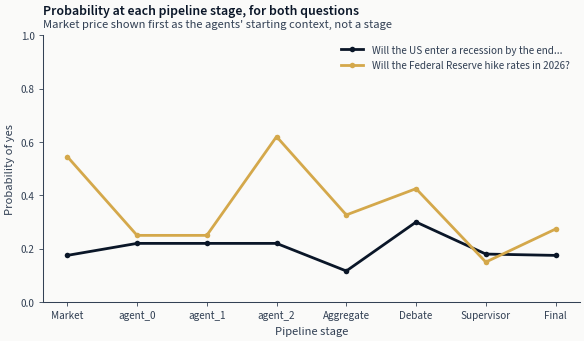

In [24]:
flow_rows = []
for r in results:
    q_short = textwrap.shorten(r.question.question, width=44, placeholder="...")
    phases = []

    if r.question.current_market_price is not None:
        phases.append(("Market", r.question.current_market_price))

    for a in r.agents:
        phases.append((a.agent_id, a.p_yes))

    if r.aggregation:
        aggregate_p = (
            r.aggregation.extremized_probability
            if r.aggregation.extremized_probability is not None
            else r.aggregation.raw_probability
        )
        phases.append(("Aggregate", aggregate_p))

    if r.debate and r.debate.bull_final_probability is not None:
        mid = (r.debate.bull_final_probability + r.debate.bear_final_probability) / 2
        phases.append(("Debate", mid))

    if r.supervisor and r.supervisor.p_yes is not None:
        phases.append(("Supervisor", r.supervisor.p_yes))

    phases.append(("Final", r.final_probability))

    for name, p in phases:
        flow_rows.append({"question": q_short, "phase": name, "p_yes": p})

flow_df = pl.DataFrame(flow_rows)

fig, ax = plt.subplots()
phase_order = flow_df["phase"].unique(maintain_order=True).to_list()
for i, (question_text, group) in enumerate(flow_df.group_by("question", maintain_order=True)):
    group = group.with_columns(pl.col("phase").cast(pl.Enum(phase_order))).sort("phase")
    ax.plot(
        group["phase"].to_list(),
        group["p_yes"].to_list(),
        marker="o",
        linewidth=2,
        color=[COLORS["blue"], COLORS["amber"]][i],
        label=question_text[0],
    )
ax.set_xlabel("Pipeline stage")
ax.set_ylabel("Probability of yes")
ax.set_ylim(0, 1)
add_message_title(
    ax,
    "Probability at each pipeline stage, for both questions",
    subtitle="Market price shown first as the agents' starting context, not a stage",
)
ax.legend(loc="upper right")
show_with_alt(
    fig,
    "Line chart of probability against pipeline stage, one line per question, running from the "
    "market price through the research agents to the aggregate, the debate midpoint, the "
    "supervisor and the final blend. Neither line is flat, and neither moves in one direction: "
    "both rise at some stages and fall at others, and the two do not move together.",
)

Which stage moved the answer is a question the chart poses and a reader should not have to
eyeball. The largest single step on each line is below, read off the same frame the chart was
drawn from.

In [25]:
largest_move = (
    flow_df.with_columns(
        pl.col("p_yes").diff().over("question").alias("move"),
        pl.col("phase").shift().over("question").alias("from_phase"),
    )
    .drop_nulls("move")
    .with_columns(pl.col("move").abs().alias("size"))
    .sort("size", descending=True)
    .group_by("question", maintain_order=True)
    .first()
    .select(
        "question",
        pl.format("{} to {}", "from_phase", "phase").alias("largest step"),
        pl.col("move").round(3),
    )
)
largest_move

question,largest step,move
str,str,f64
"""Will the Federal Reserve hike …","""agent_1 to agent_2""",0.37
"""Will the US enter a recession …","""Aggregate to Debate""",0.183


The two questions are moved most by different stages, which is the reading to take from the
chart: no stage in this pipeline is where the answer is decided, and none of them is idle
either. Whether any of that movement is an improvement is a scoring question, and neither of
these questions had resolved.

## Token use

In [26]:
print(f"  Questions forecasted: {len(results)}")
print(f"  Total tokens: {grand_total.total_tokens:,}")
print(f"  Input tokens: {grand_total.input_tokens:,}")
print(f"  Output tokens: {grand_total.output_tokens:,}")

  Questions forecasted: 2
  Total tokens: 164,463
  Input tokens: 157,016
  Output tokens: 7,447


## The Record a Scoring Pipeline Would Read

Everything above lives in memory. What a scoring or monitoring system needs is a flat record
per question: the forecast, the cutoff, the outcome if it is known, and enough of the
intermediate stages to attribute a bad forecast to one of them.

Neither of these questions had resolved when the capture was taken, so `resolved_outcome` is
empty and nothing here can be scored.
[`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb) builds the scoring rules
against a panel of questions whose outcomes are known, rather than against these two.

In [27]:
serialized = [
    {
        "question": r.question.question,
        "cutoff_date": r.question.cutoff_date,
        "final_probability": r.final_probability,
        "resolved_outcome": r.question.resolved_outcome,
        "agent_probs": [a.p_yes for a in r.agents],
        "aggregate": r.aggregation.extremized_probability if r.aggregation else None,
        "debate_consensus": r.debate.consensus_reached if r.debate else None,
        "supervisor_p_yes": r.supervisor.p_yes if r.supervisor else None,
        "supervisor_confidence": r.supervisor.confidence if r.supervisor else None,
        "tokens": r.total_token_usage.total_tokens,
        "duration_s": r.duration_seconds,
    }
    for r in results
]

print(json.dumps(serialized[0], indent=2))
print(f"\n({len(serialized)} records; the second has the same shape)")

{
  "question": "Will the US enter a recession by the end of 2026?",
  "cutoff_date": "",
  "final_probability": 0.175,
  "resolved_outcome": null,
  "agent_probs": [
    0.22,
    0.22,
    0.22
  ],
  "aggregate": 0.1166,
  "debate_consensus": false,
  "supervisor_p_yes": 0.18,
  "supervisor_confidence": "medium",
  "tokens": 82814,
  "duration_s": null
}

(2 records; the second has the same shape)


The pipeline moves a probability through four stages and records where it went. What it does
not establish is that any stage improved the estimate. The aggregation credits the panel with
an independence nobody measured. The debate narrows the two sides by a few points on the
contested question, which is a smaller disagreement and not a more accurate one. The
supervisor's confidence label is its own assertion about itself. Reading the stage-to-stage
movement as progressive refinement is the mistake this record exists to prevent, and it is
why the figure above draws the whole path rather than the endpoint.

In [28]:
recession, rate_hike = results
display(
    Markdown(
        "**This replay.** "
        f"The recession forecast ends at {recession.final_probability:.1%} and the rate-hike "
        f"forecast at {rate_hike.final_probability:.1%}, against market prices of "
        f"{recession.question.current_market_price:.1%} and "
        f"{rate_hike.question.current_market_price:.1%}. Neither distance is a comparison: "
        "both market prices were in every research agent's prompt, so the pipeline was told "
        "where the market stood before it looked at anything. And both questions were "
        "unresolved when the capture was taken, so neither forecast can be scored."
    )
)

**This replay.** The recession forecast ends at 17.5% and the rate-hike forecast at 27.4%, against market prices of 17.5% and 54.5%. Neither distance is a comparison: both market prices were in every research agent's prompt, so the pipeline was told where the market stood before it looked at anything. And both questions were unresolved when the capture was taken, so neither forecast can be scored.

## Key Takeaways

1. **The value of a pipeline is that each stage is inspectable, not that each stage improves
   the answer.** Four stages give four places to look when a forecast is wrong. Whether any
   of them made it better is a scoring question, and scoring needs resolved questions.
2. **An override needs a gate, and the gate needs a rule.** The supervisor can replace the
   ensemble only at high stated confidence, blends at medium, and is ignored at low. Without
   that, one model's second opinion silently outranks three agents' evidence.
3. **A stated confidence is not a measured one.** Both the supervisor's own label and the
   scalar this pipeline attaches to the final probability are conventions. They order
   outcomes; they do not estimate anything.
4. **Declare every constant that moves the final number in one place.** The blend
   weights, the correlation and the override thresholds decide the output, and a reader who
   cannot find them cannot evaluate the pipeline.
5. **The stage-by-stage record is the deliverable.** One JSON file per question holds every
   prompt, every document, every intermediate probability, and it is what makes a forecast
   reviewable months later.

**Known limitations of what is built here.** Both questions were unresolved when captured, so
nothing in this notebook can be scored and no claim about accuracy is available from it. The
market price is passed to every research agent, so the pipeline's distance from the market
is not an independent comparison. The blend weights and confidence scalars are conventions,
and no experiment here shows the four-stage output is better than the three-agent mean.

**Next**: [`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb) builds the
scoring rules, calibration curves and security controls a pipeline like this needs before
anyone acts on it.

**Book**: Section 24.7 covers the pipeline architecture and section 24.9 the production
considerations that follow from it.